# **Model analisis sentimen ulasan aplikasi LINE - Imelda Cyntia**

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import re
import string

# Modul NLTK untuk pemrosesan teks
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import download as nltk_download

# Mengunduh resource yang dibutuhkan dari NLTK
nltk_download('punkt')
nltk_download('stopwords')
nltk_download('wordnet')
nltk_download('punkt_tab')

# Modul Sastrawi untuk pemrosesan teks dalam bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud

# Modul Scikit-Learn untuk pemrosesan teks dan machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score
from sklearn.preprocessing import LabelEncoder

# Modul TensorFlow dan Keras untuk deep learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Conv1D, GlobalMaxPooling1D, Bidirectional, MaxPooling1D, Flatten, GRU, SimpleRNN
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

import requests
import csv
from io import StringIO
import tensorflow as tf

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


##**Load Dataset**

In [ ]:
# Membaca datset
file_path = "/content/ulasan_LINE.csv"
df = pd.read_csv(file_path)

In [ ]:
# Menampilkan 5 baris pertama dari dataset untuk eksplorasi awal
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,119a91ab-bf3f-4d6e-a384-2d3aa2f27ff0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"mau tambahkan nomor telp tapi ada notif ""no. t...",1,49,15.3.0,2025-03-27 15:43:03,NaN,NaN,15.3.0
1,25e0d93a-4bfa-43a1-a64d-ed57d04c7f94,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya memiliki pengalaman yang buruk sekali den...,1,5,15.3.1,2025-03-27 13:34:10,NaN,NaN,15.3.1
2,4b3b9c3e-fb98-4ffa-8aa8-c6b96a9fa7da,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya pengguna baru line, saat saya mendaftar m...",1,187,15.3.1,2025-03-24 09:53:13,NaN,NaN,15.3.1
3,7eca05ed-0a58-4eff-ba23-a80b0d869365,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,menambahkan teman eror/gak bisa. mengaktifkan ...,2,55,15.2.1,2025-03-22 06:43:05,NaN,NaN,15.2.1
4,46a79be0-74ff-4ff1-85a8-0b314fb12b0c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ads nya tiba-tiba muncul dan menghilang setiap...,2,54,15.2.1,2025-03-16 03:28:48,NaN,NaN,15.2.1


In [ ]:
# Menampilkan 5 baris terakhir dari dataset untuk melihat data di bagian akhir
df.tail()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
29995,e520eb40-a0fe-40b7-9bf9-78fb08c0fd3e,Nur Janah,https://play-lh.googleusercontent.com/a/ACg8oc...,Tolong pembelian stiker nya bisa pake aplikasi...,4,0,NaN,2024-01-31 08:32:46,NaN,NaN,NaN
29996,35ada47a-2a2a-4737-8eb7-5273b582496b,Haririnsyaa,https://play-lh.googleusercontent.com/a-/ALV-U...,Pokonya suka bgt sama aplikasinya.. 😊😊😊😊👍👍👍👍👍,5,0,NaN,2022-01-07 00:03:13,NaN,NaN,NaN
29997,2521cf04-ae32-42e9-9205-2fa1a990b5c4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Masa uda berapa kali instal gk bisa""gmn sih:v",2,0,7.2.2,2018-10-23 11:33:24,NaN,NaN,7.2.2
29998,5891c1ac-55bb-4fa4-b9d7-b4a0ad8e6608,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Cara menghapus teman ga ana menu nya, kurangin...",2,0,NaN,2020-01-09 00:30:10,NaN,NaN,NaN
29999,e9c0b3ed-9b21-413e-96cc-a492e27f14b8,BangRiss,https://play-lh.googleusercontent.com/a-/ALV-U...,apk nya sangat sangat bagus,5,1,13.10.1,2023-07-05 06:04:59,NaN,NaN,13.10.1


In [ ]:
# Menampilkan info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              30000 non-null  object 
 1   userName              30000 non-null  object 
 2   userImage             30000 non-null  object 
 3   content               30000 non-null  object 
 4   score                 30000 non-null  int64  
 5   thumbsUpCount         30000 non-null  int64  
 6   reviewCreatedVersion  22261 non-null  object 
 7   at                    30000 non-null  object 
 8   replyContent          0 non-null      float64
 9   repliedAt             0 non-null      float64
 10  appVersion            22261 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 2.5+ MB


## **Pre-Processing Data**

### **Menghapus Missing Value dan Duplikasi pada Kolom Content**  

Karena hanya kolom ini yang digunakan untuk pelatihan model, maka missing value dan duplikasi di dalamnya perlu dihapus.

In [ ]:
# Menghapus baris yang memiliki nilai kosong pada kolom 'content'
df_clean = df.dropna(subset=['content'])

# Menghapus baris yang memiliki data duplikat dalam dataset
df_clean = df_clean.drop_duplicates()

###**Menampilkan informasi dataset setelah proses cleaning**

In [ ]:
# Menampilkan ringkasan informasi dataset setelah pembersihan
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              30000 non-null  object 
 1   userName              30000 non-null  object 
 2   userImage             30000 non-null  object 
 3   content               30000 non-null  object 
 4   score                 30000 non-null  int64  
 5   thumbsUpCount         30000 non-null  int64  
 6   reviewCreatedVersion  22261 non-null  object 
 7   at                    30000 non-null  object 
 8   replyContent          0 non-null      float64
 9   repliedAt             0 non-null      float64
 10  appVersion            22261 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 2.5+ MB


### **Mendefinisikan Fungsi-Fungsi untuk Pemrosesan Teks**  

Berikut adalah beberapa fungsi yang digunakan untuk membersihkan dan memproses teks sebelum dianalisis:  

- **`cleaningText`** → Menghapus mentions, hashtag, RT, tautan, serta angka dari teks.  
- **`caseFoldingText`** → Mengonversi semua huruf dalam teks menjadi huruf kecil.  
- **`tokenizingText`** → Memisahkan teks menjadi daftar kata atau token.  
- **`filteringText`** → Menghilangkan stopwords dalam bahasa Indonesia maupun Inggris.  
- **`stemmingText`** → Mengembalikan kata ke bentuk dasarnya. Fungsi ini tidak digunakan dalam proyek ini karena membutuhkan waktu pemrosesan yang cukup lama.  
- **`toSentence`** → Menyatukan kembali teks yang telah dipecah menjadi token sebelumnya.  

In [ ]:
# Fungsi untuk membersihkan teks
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # Menghapus mentions
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)  # Menghapus hashtag
    text = re.sub(r'RT\s+', '', text)  # Menghapus RT
    text = re.sub(r'http\S+', '', text)  # Menghapus link
    text = re.sub(r'\d+', '', text)  # Menghapus angka
    text = re.sub(r'[^\w\s]', '', text)  # Menghapus tanda baca
    text = text.replace('\n', ' ')  # Mengganti baris baru dengan spasi
    text = text.strip()  # Menghapus spasi di awal & akhir teks
    return text

# Fungsi untuk mengubah teks menjadi huruf kecil
def casefoldingText(text):
    return text.lower()

# Fungsi untuk tokenisasi teks
def tokenizingText(text):
    return word_tokenize(text)

# Fungsi untuk menghapus stopwords
def filteringText(text):
    stopwords_ind = set(stopwords.words('indonesian'))
    stopwords_eng = set(stopwords.words('english'))

    # Menambahkan beberapa stopwords tambahan
    additional_stopwords = {'iya', 'yaa', 'gak', 'nya', 'na', 'sih', 'ku',
                            'di', 'ga', 'ya', 'gaa', 'loh', 'kah', 'woi',
                            'woii', 'woy'}

    all_stopwords = stopwords_ind.union(stopwords_eng, additional_stopwords)

    return [word for word in text if word.lower() not in all_stopwords]  # Pastikan semuanya dalam lowercase

# Fungsi untuk stemming (tidak digunakan dalam proyek ini karena lambat)
def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    words = text.split()  # Pastikan input adalah string
    return ' '.join(stemmer.stem(word) for word in words)

# Fungsi untuk menggabungkan kembali token menjadi teks
def toSentence(tokens):
    return ' '.join(tokens)


### **Mengubah slangwords menjadi bentuk baku**

In [ ]:
# Kamus slang words ke bentuk baku
slangwords = {
    "trs2": "terus-terusan", "bsa": "bisa", "udh2": "sudah-sudah", "gt": "gitu",
    "cm": "cuma", "pdhl": "padahal", "sbnernya": "sebenarnya", "bs": "bisa",
    "skrg": "sekarang", "gmn": "gimana", "dy": "dia", "lgsg": "langsung",
    "utk": "untuk", "bgtu": "begitu", "sbnrnya": "sebenarnya", "sbnr": "sebenarnya",
    "blg": "bilang", "gmnnih": "gimana ini", "jdnya": "jadinya", "brrti": "berarti",
    "klian": "kalian", "bgtu2": "begitu-begitu", "jdg": "jadi juga", "smpe": "sampai",
    "pke": "pakai", "klw": "kalau", "dlm": "dalam", "sbrng": "sebarang",
    "dmn": "dimana", "ttp": "tetap", "klian2": "kalian-kalian", "brp": "berapa",
    "sll": "selalu", "gkngaruh": "tidak ngaruh", "jdul": "judul", "tmn": "teman",
    "mrk": "mereka", "msih": "masih", "py": "punya", "nnti": "nanti",
    "nyoba": "mencoba", "brkt": "berangkat", "btw": "by the way", "smw": "semua",
    "ktmu": "ketemu", "ampe": "sampai", "dg": "dengan", "sblm": "sebelum",
    "psn": "pesan", "pny": "punya", "drpd": "daripada", "skli": "sekali",
    "brpa": "berapa", "sm2": "sama-sama", "bsok": "besok", "bntar": "sebentar",
    "gmn2": "gimana-gimana", "udh3": "sudah-sudah-sudah", "psti": "pasti",
    "jln": "jalan", "mgkn": "mungkin", "nnti2": "nanti-nanti", "mshh": "masih",
    "bkin": "bikin", "gaada2": "tidak ada-ada", "smpe2": "sampai-sampai",
    "bgt2": "banget-banget", "kta": "kata", "brpa2": "berapa-berapa",
    "mnt": "menit", "stlh": "setelah", "mrasa": "merasa", "biasa2": "biasa-biasa",
    "brt": "berat", "skr": "sekarang", "psti2": "pasti-pasti",
    "bsar": "besar", "bnr": "benar", "krna": "karena", "jdi": "jadi",
    "sbnr2": "sebenarnya-sebenarnya", "mlm": "malam", "tmen": "teman",
    "byk": "banyak", "bnran": "beneran", "hbis": "habis", "ajh": "aja",
    "trlalu": "terlalu", "gaperlu": "tidak perlu", "sblmnya": "sebelumnya",
    "bener2": "benar-benar", "prnah": "pernah", "smcm": "semacam",
    "mreka": "mereka", "krn2": "karena-karena", "tp2": "tapi-tapi",
    "mgkin": "mungkin", "ak": "aku", "knp2": "kenapa-kenapa",
    "apapun": "apa pun", "trlalu2": "terlalu-terlalu"
}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [ ]:
# Menampilkan dataset yang telah dibersihkan
df_clean.head(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,119a91ab-bf3f-4d6e-a384-2d3aa2f27ff0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"mau tambahkan nomor telp tapi ada notif ""no. t...",1,49,15.3.0,2025-03-27 15:43:03,NaN,NaN,15.3.0
1,25e0d93a-4bfa-43a1-a64d-ed57d04c7f94,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya memiliki pengalaman yang buruk sekali den...,1,5,15.3.1,2025-03-27 13:34:10,NaN,NaN,15.3.1
2,4b3b9c3e-fb98-4ffa-8aa8-c6b96a9fa7da,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya pengguna baru line, saat saya mendaftar m...",1,187,15.3.1,2025-03-24 09:53:13,NaN,NaN,15.3.1
3,7eca05ed-0a58-4eff-ba23-a80b0d869365,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,menambahkan teman eror/gak bisa. mengaktifkan ...,2,55,15.2.1,2025-03-22 06:43:05,NaN,NaN,15.2.1
4,46a79be0-74ff-4ff1-85a8-0b314fb12b0c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ads nya tiba-tiba muncul dan menghilang setiap...,2,54,15.2.1,2025-03-16 03:28:48,NaN,NaN,15.2.1


### **Menerapkan preprocessing text pada dataset**

In [ ]:
# Membersihkan teks dan menyimpannya di kolom 'clean_text'
df_clean['clean_text'] = df_clean['content'].apply(cleaningText)

# Mengonversi teks ke huruf kecil dan menyimpannya di 'lowercase_text'
df_clean['lowercase_text'] = df_clean['clean_text'].apply(casefoldingText)

# Mengonversi slang words menjadi kata standar dan menyimpannya di 'normalized_text'
df_clean['normalized_text'] = df_clean['lowercase_text'].apply(fix_slangwords)

# Melakukan tokenisasi teks dan menyimpannya di 'tokenized_text'
df_clean['tokenized_text'] = df_clean['normalized_text'].apply(tokenizingText)

# Menghapus kata-kata umum (stopwords) dan menyimpannya di 'filtered_text'
df_clean['filtered_text'] = df_clean['tokenized_text'].apply(filteringText)

# Menggabungkan kembali token-token menjadi teks yang sudah diproses dan menyimpannya di 'final_text'
df_clean['final_text'] = df_clean['filtered_text'].apply(toSentence)

### **Menampilkan dataset setelah cleaning**

In [ ]:
# Menampilkan dataset setelah preprocessing text
df_clean.head(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,clean_text,lowercase_text,normalized_text,tokenized_text,filtered_text,final_text
0,119a91ab-bf3f-4d6e-a384-2d3aa2f27ff0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"mau tambahkan nomor telp tapi ada notif ""no. t...",1,49,15.3.0,2025-03-27 15:43:03,NaN,NaN,15.3.0,mau tambahkan nomor telp tapi ada notif no tel...,mau tambahkan nomor telp tapi ada notif no tel...,mau tambahkan nomor telp tapi ada notif no tel...,"[mau, tambahkan, nomor, telp, tapi, ada, notif...","[tambahkan, nomor, telp, notif, telepon, negar...",tambahkan nomor telp notif telepon negarawilay...
1,25e0d93a-4bfa-43a1-a64d-ed57d04c7f94,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya memiliki pengalaman yang buruk sekali den...,1,5,15.3.1,2025-03-27 13:34:10,NaN,NaN,15.3.1,saya memiliki pengalaman yang buruk sekali den...,saya memiliki pengalaman yang buruk sekali den...,saya memiliki pengalaman yang buruk sekali den...,"[saya, memiliki, pengalaman, yang, buruk, seka...","[memiliki, pengalaman, buruk, line, mencari, i...",memiliki pengalaman buruk line mencari id tema...
2,4b3b9c3e-fb98-4ffa-8aa8-c6b96a9fa7da,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya pengguna baru line, saat saya mendaftar m...",1,187,15.3.1,2025-03-24 09:53:13,NaN,NaN,15.3.1,saya pengguna baru line saat saya mendaftar me...,saya pengguna baru line saat saya mendaftar me...,saya pengguna baru line saat saya mendaftar me...,"[saya, pengguna, baru, line, saat, saya, menda...","[pengguna, line, mendaftar, akun, google, deka...",pengguna line mendaftar akun google dekali err...
3,7eca05ed-0a58-4eff-ba23-a80b0d869365,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,menambahkan teman eror/gak bisa. mengaktifkan ...,2,55,15.2.1,2025-03-22 06:43:05,NaN,NaN,15.2.1,menambahkan teman erorgak bisa mengaktifkan ad...,menambahkan teman erorgak bisa mengaktifkan ad...,menambahkan teman erorgak bisa mengaktifkan ad...,"[menambahkan, teman, erorgak, bisa, mengaktifk...","[teman, erorgak, mengaktifkan, add, teman, oto...",teman erorgak mengaktifkan add teman otomatis ...
4,46a79be0-74ff-4ff1-85a8-0b314fb12b0c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ads nya tiba-tiba muncul dan menghilang setiap...,2,54,15.2.1,2025-03-16 03:28:48,NaN,NaN,15.2.1,ads nya tibatiba muncul dan menghilang setiap ...,ads nya tibatiba muncul dan menghilang setiap ...,ads nya tibatiba muncul dan menghilang setiap ...,"[ads, nya, tibatiba, muncul, dan, menghilang, ...","[ads, tibatiba, muncul, menghilang, percakapan...",ads tibatiba muncul menghilang percakapan meng...


### **Mengunduh Lexicon Positif dan Negatif dari GitHub**  

Lexicon positif dan negatif berisi daftar kata yang digunakan untuk menganalisis sentimen dalam teks. Dengan mengunduhnya dari GitHub, kita dapat memperoleh referensi kata yang lebih luas dan akurat untuk meningkatkan performa model dalam mengklasifikasikan sentimen.

In [ ]:
# Fungsi untuk mengunduh dan membaca lexicon dari GitHub
def load_lexicon(url):
    lexicon = {}
    try:
        response = requests.get(url)
        response.raise_for_status()  # Cek jika request gagal

        reader = csv.reader(StringIO(response.text), delimiter=',')
        for row in reader:
            if len(row) == 2:  # Memastikan format CSV valid (dua kolom)
                word = row[0].strip()
                try:
                    score = int(row[1].strip())  # Konversi skor ke integer
                    lexicon[word] = score
                except ValueError:
                    print(f"Kesalahan format angka pada kata: {word}")
    except requests.RequestException as e:
        print(f"Gagal mengunduh data dari {url}: {e}")

    return lexicon

# URL lexicon positif dan negatif
url_positive = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
url_negative = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'

# Load lexicon
lexicon_positive = load_lexicon(url_positive)
lexicon_negative = load_lexicon(url_negative)

# Menampilkan jumlah kata dalam lexicon
print(f"Jumlah kata positif: {len(lexicon_positive)}")
print(f"Jumlah kata negatif: {len(lexicon_negative)}")

Jumlah kata positif: 3609
Jumlah kata negatif: 6607


### **Mendefinisikan Fungsi untuk Menghitung Polaritas Sentimen**  

Fungsi ini bertujuan untuk menentukan apakah suatu teks memiliki sentimen positif, netral, atau negatif berdasarkan kata-kata yang terkandung di dalamnya. Dengan membandingkan kata-kata dalam teks terhadap lexicon positif dan negatif, fungsi ini dapat memberikan skor polaritas yang digunakan sebagai label sentimen dalam model analisis.

In [ ]:
# Fungsi untuk menganalisis sentimen menggunakan lexicon bahasa Indonesia
def analyze_sentiment_lexicon(text):
    score = 0  # Inisialisasi skor sentimen

    # Menilai setiap kata dalam teks
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]  # Tambahkan skor jika kata positif
        elif word in lexicon_negative:
            score += lexicon_negative[word]  # Kurangkan skor jika kata negatif

    # Menentukan polaritas berdasarkan skor
    if score >= 0:
        polarity = 'positive'
    elif score <= -7:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

## **Pelabelan Data**



### **Menghitung polaritas**

In [ ]:
# Memberi label pada teks dengan analisis sentimen
results = df_clean['filtered_text'].apply(analyze_sentiment_lexicon)
results = list(zip(*results))  # Memisahkan skor dan polaritas

# Menambahkan hasil analisis ke dalam dataset
df_clean['polarity_score'] = results[0]  # Skor sentimen
df_clean['polarity'] = results[1]  # Label sentimen (positive, neutral, negative)

# Menampilkan jumlah masing-masing polaritas
print(df_clean['polarity'].value_counts())

polarity
positive    18949
neutral      7751
negative     3300
Name: count, dtype: int64


**Beberapa insight yang dapat diambil:**  
1. **Dominasi Sentimen Positif** – Sebagian besar teks dalam dataset memiliki sentimen positif, yang bisa mengindikasikan bahwa mayoritas ulasan atau komentar cenderung memberikan apresiasi atau respon baik.  
2. **Proporsi Sentimen Netral yang Signifikan** – Sentimen netral cukup banyak (7.751 sampel), yang berarti terdapat banyak teks yang tidak menunjukkan emosi yang jelas atau berisi opini yang seimbang.  
3. **Sentimen Negatif Lebih Sedikit** – Hanya 3.300 sampel yang memiliki sentimen negatif, yang bisa menunjukkan bahwa keluhan atau kritik lebih jarang dibandingkan dengan ulasan positif.  


## **Data understanding**



###**Memvisualisasikan distribusi polarity_score menggunakan histogram**

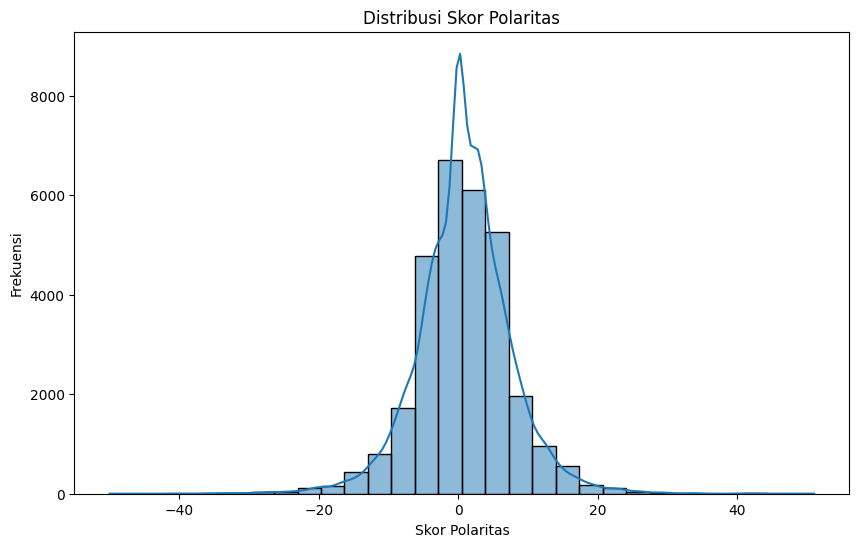

In [ ]:
# Menampilkan distribusi polarity_score dengan histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['polarity_score'], bins=30, kde=True)
plt.title('Distribusi Skor Polaritas')
plt.xlabel('Skor Polaritas')
plt.ylabel('Frekuensi')
plt.show()

### **Memvisualisasikan pembagian dataset dengan diagram lingkaran.**

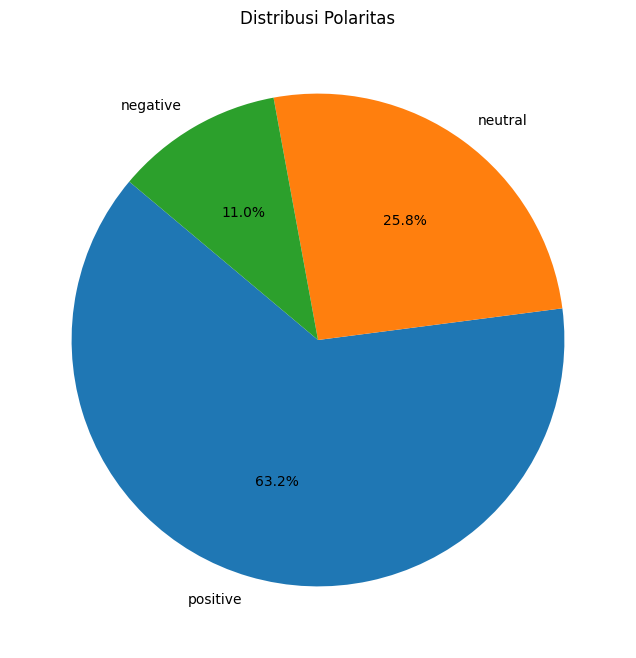

In [ ]:
# Hitung jumlah masing-masing kategori polaritas
polarity_counts = df_clean['polarity'].value_counts()

# Menampilkan diagram lingkaran
plt.figure(figsize=(8, 8))
plt.pie(polarity_counts, labels=polarity_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribusi Polaritas')
plt.show()

Mayoritas ulasan dalam data memiliki sentimen positif (63.2%), menunjukkan kepuasan pengguna yang tinggi. Sentimen netral (25.8%) cukup signifikan, mengindikasikan adanya ulasan yang tidak condong ke arah tertentu. Sementara itu, sentimen negatif hanya 11.0%, menandakan keluhan relatif sedikit. Meskipun dominasi sentimen positif mengindikasikan pengalaman yang baik, ulasan netral dan negatif tetap perlu dianalisis untuk perbaikan lebih lanjut.

## **Word cloud umum**


###**Membuat wordcloud dari dataset tanpa melihat label**

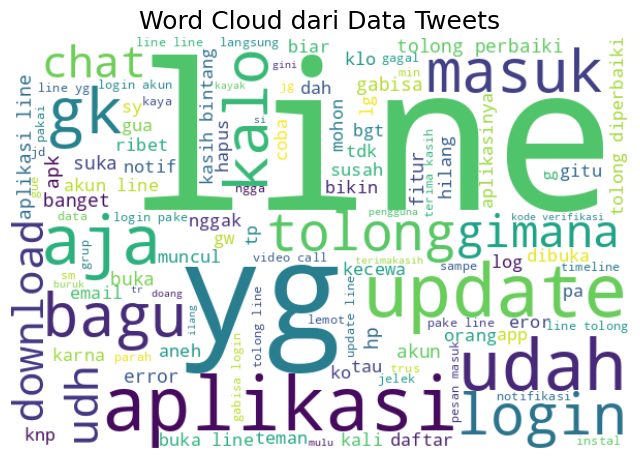

In [ ]:
# Membuat word cloud dari dataset tanpa melihat label

# Menggabungkan semua kata dari kolom 'filtered_text' menjadi satu string
all_words = ' '.join([' '.join(tweet) for tweet in df_clean['filtered_text']])

# Membuat word cloud
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(all_words)

# Menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud dari Data Tweets', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')  # Menghilangkan sumbu
plt.show()

### **Word cloud positive**

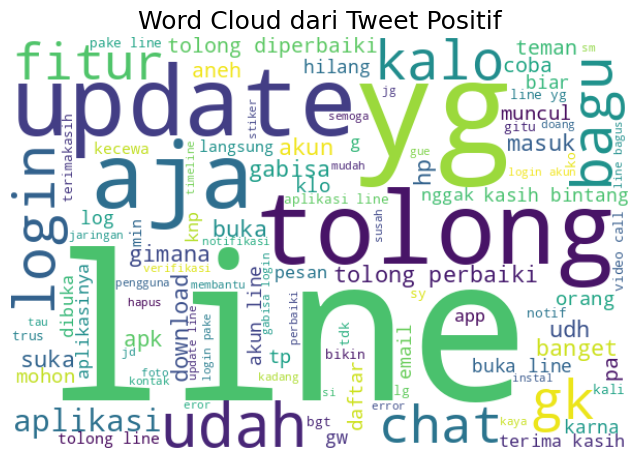

In [ ]:
# Mengatur tampilan maksimum kolom
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame khusus untuk tweet dengan sentimen positif
positive_tweets = df_clean[df_clean['polarity'] == 'positive'][['final_text', 'polarity_score', 'polarity', 'filtered_text']] # Changed 'text_akhir' and 'text_stopword' with 'final_text' and 'filtered_text'

# Mengurutkan berdasarkan skor polaritas secara descending
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False).reset_index(drop=True)

# Mengatur indeks agar dimulai dari 1
positive_tweets.index += 1

# Menggabungkan semua kata dalam tweet positif menjadi satu string
positive_words = ' '.join([' '.join(tweet) for tweet in positive_tweets['filtered_text']]) # Changed 'text_stopword' with 'filtered_text'

# Membuat word cloud dari tweet positif
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(positive_words)

# Menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud dari Tweet Positif', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')  # Menghilangkan sumbu
plt.show()

###**Word cloud negative**

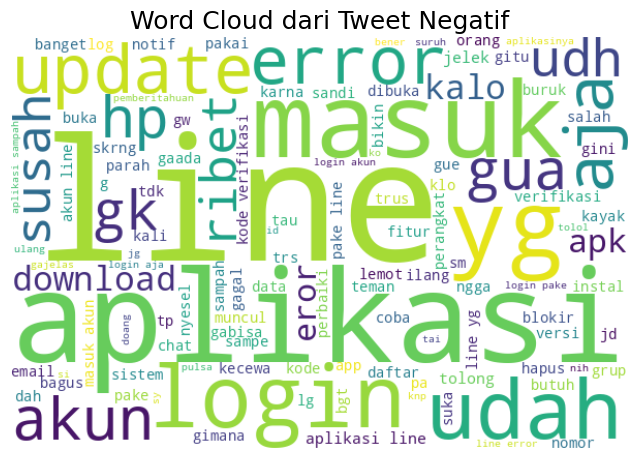

In [ ]:
# Mengatur tampilan maksimum kolom
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame khusus untuk tweet dengan sentimen negatif
negative_tweets = df_clean[df_clean['polarity'] == 'negative'][['final_text', 'polarity_score', 'polarity', 'filtered_text']]

# Mengurutkan berdasarkan skor polaritas secara ascending
negative_tweets = negative_tweets.sort_values(by='polarity_score').reset_index(drop=True)

# Mengatur indeks agar dimulai dari 1
negative_tweets.index += 1

# Menggabungkan semua kata dalam tweet negatif menjadi satu string
negative_words = ' '.join([' '.join(tweet) for tweet in negative_tweets['filtered_text']])

# Membuat word cloud dari tweet negatif dengan warna netral
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(negative_words)

# Menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud dari Tweet Negatif', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')  # Menghilangkan sumbu
plt.show()

###**Word cloud neutral**

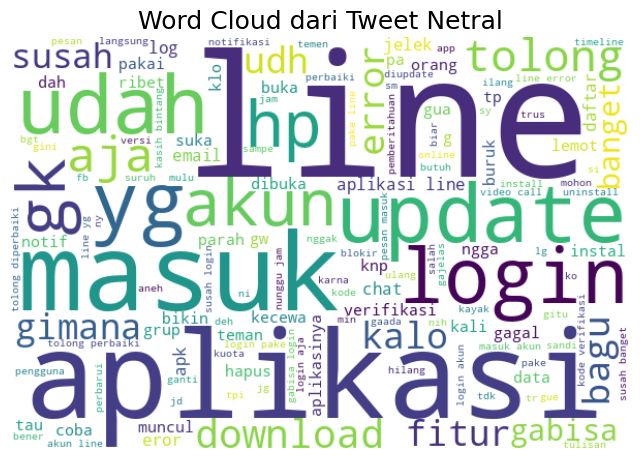

In [ ]:
# Mengatur tampilan maksimum kolom
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame khusus untuk tweet dengan sentimen netral
neutral_tweets = df_clean[df_clean['polarity'] == 'neutral'][['final_text', 'polarity_score', 'polarity', 'filtered_text']]

# Mengurutkan berdasarkan skor polaritas secara ascending
neutral_tweets = neutral_tweets.sort_values(by='polarity_score').reset_index(drop=True)

# Mengatur indeks agar dimulai dari 1
neutral_tweets.index += 1

# Menggabungkan semua kata dalam tweet netral menjadi satu string
neutral_words = ' '.join([' '.join(tweet) for tweet in neutral_tweets['filtered_text']])

# Membuat word cloud dari tweet netral dengan warna netral
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(neutral_words)

# Menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud dari Tweet Netral', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')  # Menghilangkan sumbu
plt.show()

## **Visualisasi dataset**


### **Menampilkan distribusi dari panjang text**

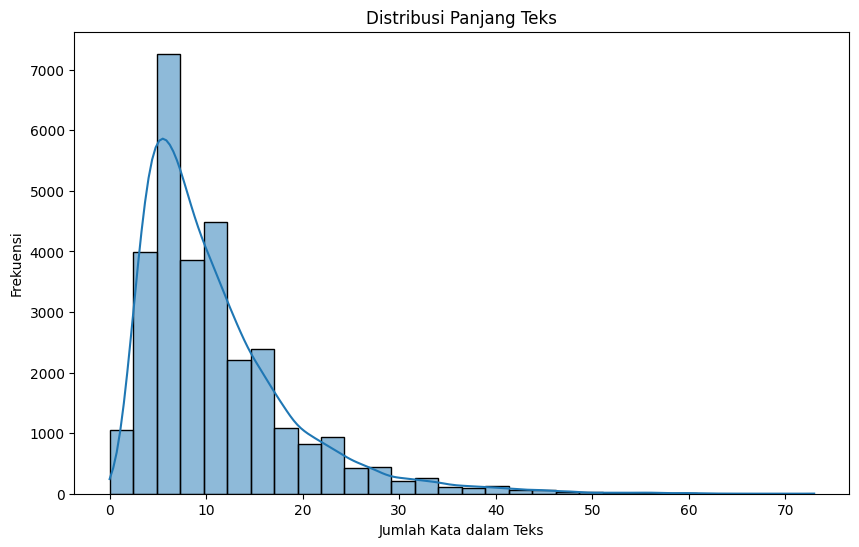

In [ ]:
plt.figure(figsize=(10, 6))

# Menambahkan kolom baru untuk panjang teks (jumlah kata dalam 'final_text')
df_clean['text_length'] = df_clean['final_text'].apply(lambda x: len(x.split()))

# Menampilkan distribusi panjang teks menggunakan histogram
sns.histplot(df_clean['text_length'], bins=30, kde=True)
plt.title('Distribusi Panjang Teks')
plt.xlabel('Jumlah Kata dalam Teks')
plt.ylabel('Frekuensi')
plt.show()

### **Menampilkan kata yang paling sering muncul**


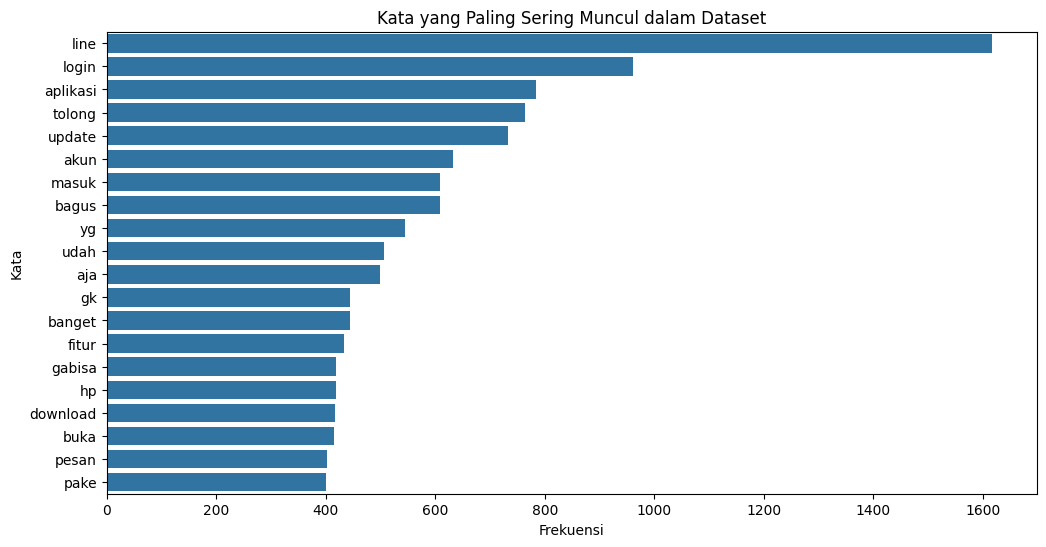

In [ ]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_clean['final_text'])  # Sesuaikan dengan variabel yang digunakan
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)

# Menampilkan kata yang paling sering muncul dengan barplot
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Kata yang Paling Sering Muncul dalam Dataset')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

## **Pembuatan Model**  

Dalam proses pembangunan model, dilakukan tiga eksperimen dengan skema pelatihan yang berbeda. Setiap model menggunakan kombinasi algoritma dan proporsi pembagian data yang bervariasi sebagai berikut:  

- **Model 1**  
  - **Algoritma:** LSTM  
  - **Proporsi Data:** 70% Training, 20% Validasi, 10% Uji  

- **Model 2**  
  - **Algoritma:** CNN  
  - **Proporsi Data:** 80% Training, 10% Validasi, 10% Uji  

- **Model 3**  
  - **Algoritma:** GRU  
  - **Proporsi Data:** 90% Training, 5% Validasi, 5% Uji  

Pendekatan ini memungkinkan analisis terhadap performa masing-masing model berdasarkan variasi algoritma serta pembagian data yang digunakan.

In [ ]:
# Menggunakan kolom 'final_text' sebagai fitur dan 'polarity' sebagai target
X = df_clean['final_text']
y = df_clean['polarity']

### **Melakukan tokenisasi**

In [ ]:
# Tokenisasi teks dengan jumlah fitur maksimal 2500
max_words = 2500
tokenizer = Tokenizer(num_words=max_words, split=' ')
tokenizer.fit_on_texts(X.values)  # Membuat indeks kata berdasarkan dataset
X_sequences = tokenizer.texts_to_sequences(X.values)  # Mengonversi teks ke dalam bentuk numerik
X_padded = pad_sequences(X_sequences)  # Menyamakan panjang setiap urutan

# Encoding label target ke dalam bentuk numerik dan one-hot encoding
encoder = LabelEncoder()
y_numeric = encoder.fit_transform(y)  # Mengonversi label kategori menjadi angka
y_onehot = to_categorical(y_numeric)  # Mengubah ke format one-hot encoding

# Menentukan jumlah kelas dari data target
num_labels = y_onehot.shape[1]

### **Menentukan callback yang akan menghentikan pelatihan secara otomatis jika akurasi training melebihi 0.95**

In [ ]:
# Callback untuk menghentikan pelatihan jika akurasi validasi sudah cukup tinggi
class EarlyStopAtHighAccuracy(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs and logs.get('val_accuracy', 0) > 0.92:
            print(f"\nPelatihan dihentikan karena akurasi validasi sudah mencapai lebih dari 92% pada epoch {epoch+1}.")
            self.model.stop_training = True

early_stopping = EarlyStopAtHighAccuracy()

## Model 1 - LSTM

In [ ]:
# Memisahkan data menjadi train, validation, dan test set
X_train_full, X_test_LSTM, y_train_full, y_test_LSTM = train_test_split(X_padded, y_onehot, test_size=0.1, random_state=42)
X_train_LSTM, X_val_LSTM, y_train_LSTM, y_val_LSTM = train_test_split(X_train_full, y_train_full, test_size=2/9, random_state=42)

In [ ]:
# Membangun arsitektur model LSTM
model_LSTM = Sequential()
model_LSTM.add(Embedding(max_words, 256, input_length=X_padded.shape[1]))  # Lapisan embedding
model_LSTM.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01), return_sequences=True))
model_LSTM.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01)))
model_LSTM.add(Dense(128, activation='relu'))
model_LSTM.add(Dense(64, activation='relu'))
model_LSTM.add(Dense(num_labels, activation='softmax'))  # Output sesuai jumlah kelas

# Kompilasi model
model_LSTM.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Melatih model dengan early stopping kustom
batch_size = 2056
history_LSTM = model_LSTM.fit(
    X_train_LSTM, y_train_LSTM,
    epochs=50,
    batch_size=batch_size,
    validation_data=(X_val_LSTM, y_val_LSTM),
    verbose=2,
    callbacks=[early_stopping]
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


11/11 - 74s - 7s/step - accuracy: 0.5836 - loss: 5.4312 - val_accuracy: 0.6355 - val_loss: 4.5032
Epoch 2/50
11/11 - 84s - 8s/step - accuracy: 0.6298 - loss: 3.9953 - val_accuracy: 0.6355 - val_loss: 3.3517
Epoch 3/50
11/11 - 77s - 7s/step - accuracy: 0.6298 - loss: 2.9898 - val_accuracy: 0.6355 - val_loss: 2.5293
Epoch 4/50
11/11 - 92s - 8s/step - accuracy: 0.6298 - loss: 2.2760 - val_accuracy: 0.6355 - val_loss: 1.9534
Epoch 5/50
11/11 - 98s - 9s/step - accuracy: 0.6298 - loss: 1.7729 - val_accuracy: 0.6355 - val_loss: 1.5240
Epoch 6/50
11/11 - 105s - 10s/step - accuracy: 0.6481 - loss: 1.3727 - val_accuracy: 0.6988 - val_loss: 1.1656
Epoch 7/50
11/11 - 84s - 8s/step - accuracy: 0.7202 - loss: 1.0492 - val_accuracy: 0.7558 - val_loss: 0.9155
Epoch 8/50
11/11 - 80s - 7s/step - accuracy: 0.7856 - loss: 0.8039 - val_accuracy: 0.7898 - val_loss: 0.7300
Epoch 9/50
11/11 - 61s - 6s/step - accuracy: 0.8312 - loss: 0.6245 - val_accuracy: 0.8410 - val_loss: 0.5712
Epoch 10/50
11/11 - 62s - 6s

In [ ]:
# Evaluasi model pada data uji
test_loss_LSTM, test_acc_LSTM = model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
print(f"Test Loss: {test_loss_LSTM:.2f}")
print(f"Test Accuracy: {test_acc_LSTM:.2f}")

94/94 - 4s - 44ms/step - accuracy: 0.9050 - loss: 0.3383
Test Loss: 0.34
Test Accuracy: 0.90


In [ ]:
# Menyimpan model yang telah dilatih
model_LSTM.save('model_LSTM.h5')

## Model 2 - CNN

In [ ]:
# Memisahkan dataset menjadi training, validation, dan test set
X_train_full, X_test_CNN, y_train_full, y_test_CNN = train_test_split(X_padded, y_onehot, test_size=0.1, random_state=42)
X_train_CNN, X_val_CNN, y_train_CNN, y_val_CNN = train_test_split(X_train_full, y_train_full, test_size=1/9, random_state=42)

In [ ]:
# Membangun model CNN untuk klasifikasi
model_CNN = Sequential()
model_CNN.add(Embedding(max_words, 512, input_length=X_padded.shape[1]))
model_CNN.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model_CNN.add(MaxPooling1D(pool_size=2))
model_CNN.add(Flatten())
model_CNN.add(Dense(64, activation='relu'))
model_CNN.add(Dropout(0.5))
model_CNN.add(Dense(num_labels, activation='softmax'))

# Kompilasi model
model_CNN.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Melatih model dengan early stopping kustom
batch_size = 2056
history_CNN = model_CNN.fit(
    X_train_CNN, y_train_CNN,
    epochs=50,
    batch_size=batch_size,
    validation_data=(X_val_CNN, y_val_CNN),
    verbose=2,
    callbacks=[early_stopping]
)

Epoch 1/50
12/12 - 54s - 4s/step - accuracy: 0.6014 - loss: 0.9264 - val_accuracy: 0.6360 - val_loss: 0.8617
Epoch 2/50
12/12 - 78s - 6s/step - accuracy: 0.6300 - loss: 0.8581 - val_accuracy: 0.6360 - val_loss: 0.8007
Epoch 3/50
12/12 - 79s - 7s/step - accuracy: 0.6507 - loss: 0.7379 - val_accuracy: 0.7187 - val_loss: 0.6441
Epoch 4/50
12/12 - 46s - 4s/step - accuracy: 0.7499 - loss: 0.5731 - val_accuracy: 0.7907 - val_loss: 0.5069
Epoch 5/50
12/12 - 82s - 7s/step - accuracy: 0.8183 - loss: 0.4515 - val_accuracy: 0.8497 - val_loss: 0.4041
Epoch 6/50
12/12 - 81s - 7s/step - accuracy: 0.8641 - loss: 0.3573 - val_accuracy: 0.8750 - val_loss: 0.3413
Epoch 7/50
12/12 - 81s - 7s/step - accuracy: 0.8968 - loss: 0.2884 - val_accuracy: 0.8863 - val_loss: 0.3052
Epoch 8/50
12/12 - 83s - 7s/step - accuracy: 0.9177 - loss: 0.2432 - val_accuracy: 0.8973 - val_loss: 0.2901
Epoch 9/50
12/12 - 81s - 7s/step - accuracy: 0.9334 - loss: 0.2064 - val_accuracy: 0.9013 - val_loss: 0.3121
Epoch 10/50
12/12 -

In [ ]:
# Evaluasi model pada data uji
test_loss_CNN, test_acc_CNN = model_CNN.evaluate(X_test_CNN, y_test_CNN, batch_size=1028, verbose=2)
print(f"Test Loss: {test_loss_CNN:.2f}")
print(f"Test Accuracy: {test_acc_CNN:.2f}")

3/3 - 3s - 972ms/step - accuracy: 0.8770 - loss: 0.9715
Test Loss: 0.97
Test Accuracy: 0.88


In [ ]:
model_CNN.save('model_CNN.h5')

## Model 3 - GRU

In [ ]:
# Membagi dataset menjadi data latih, validasi, dan uji untuk model GRU
X_train_full, X_test_GRU, y_train_full, y_test_GRU = train_test_split(X_padded, y_onehot, test_size=0.05, random_state=42)
X_train_GRU, X_val_GRU, y_train_GRU, y_val_GRU = train_test_split(X_train_full, y_train_full, test_size=0.0526, random_state=42)

In [ ]:
# Membangun model GRU
model_GRU = Sequential()
model_GRU.add(Embedding(input_dim=max_words, output_dim=512, input_length=X_padded.shape[1]))
model_GRU.add(SpatialDropout1D(0.3))
model_GRU.add(Bidirectional(GRU(64, return_sequences=True)))
model_GRU.add(Bidirectional(GRU(128, return_sequences=False)))
model_GRU.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model_GRU.add(Dropout(0.5))
model_GRU.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model_GRU.add(Dropout(0.5))
model_GRU.add(Dense(num_labels, activation='softmax'))

# Kompilasi model
model_GRU.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Melatih model dengan early stopping
batch_size = 1028
history_GRU = model_GRU.fit(
    X_train_GRU, y_train_GRU,
    epochs=20,
    batch_size=batch_size,
    validation_data=(X_val_GRU, y_val_GRU),
    verbose=2,
    callbacks=[early_stopping]
)

Epoch 1/20
27/27 - 194s - 7s/step - accuracy: 0.5980 - loss: 2.9099 - val_accuracy: 0.6633 - val_loss: 2.1397
Epoch 2/20
27/27 - 175s - 6s/step - accuracy: 0.7431 - loss: 1.6893 - val_accuracy: 0.8440 - val_loss: 1.1822
Epoch 3/20
27/27 - 202s - 7s/step - accuracy: 0.8587 - loss: 0.9946 - val_accuracy: 0.8853 - val_loss: 0.7619
Epoch 4/20
27/27 - 206s - 8s/step - accuracy: 0.9020 - loss: 0.6454 - val_accuracy: 0.9040 - val_loss: 0.5239
Epoch 5/20
27/27 - 197s - 7s/step - accuracy: 0.9251 - loss: 0.4470 - val_accuracy: 0.8947 - val_loss: 0.4210
Epoch 6/20

Pelatihan dihentikan karena akurasi validasi sudah mencapai lebih dari 92% pada epoch 6.
27/27 - 142s - 5s/step - accuracy: 0.9374 - loss: 0.3370 - val_accuracy: 0.9253 - val_loss: 0.3277


In [39]:
# Evaluasi model pada data uji
test_loss_GRU, test_acc_GRU = model_GRU.evaluate(X_test_GRU, y_test_GRU, verbose=2)
print(f"Test Loss: {test_loss_GRU:.2f}")
print(f"Test Accuracy: {test_acc_GRU:.2f}")

47/47 - 5s - 96ms/step - accuracy: 0.9220 - loss: 0.3614
Test Loss: 0.36
Test Accuracy: 0.92


In [40]:
# Menyimpan model ke dalam file
model_GRU.save('model_GRU.h5')

# Evaluasi model

Untuk membandingkan akurasi model LSTM, CNN, dan GRU berdasarkan hasil pelatihan dan pengujian.

In [41]:
# Membuat DataFrame untuk menyimpan hasil evaluasi model
results_df = pd.DataFrame({
    'Model': ['LSTM', 'CNN', 'GRU'],
    'Accuracy Train': [
        history_LSTM.history['accuracy'][-1],
        history_CNN.history['accuracy'][-1],
        history_GRU.history['accuracy'][-1]
    ],
    'Accuracy Test': [
        test_acc_LSTM,
        test_acc_CNN,
        test_acc_GRU
    ]
})

# Menampilkan hasil evaluasi
results_df

,Model,Accuracy Train,Accuracy Test
0,LSTM,0.968619,0.905
1,CNN,0.997792,0.877
2,GRU,0.937407,0.922


Hasil evaluasi menunjukkan bahwa model GRU memiliki keseimbangan terbaik dengan akurasi pelatihan 93.74% dan akurasi pengujian 92.2%, menjadikannya model yang paling optimal. Model LSTM memiliki akurasi pelatihan 96.86% dan akurasi pengujian 90.5%, sedangkan CNN mencapai akurasi pelatihan tertinggi sebesar 99.77% namun akurasi pengujian 87.7%. Secara keseluruhan, GRU menjadi pilihan terbaik untuk menangani data baru dengan baik.

# Predict

Predict ini digunakan untuk menguji performa model yang telah dilatih (LSTM, CNN, dan GRU) dalam mengklasifikasikan sentimen dari teks ulasan pengguna aplikasi LINE.

Tujuan dari kode ini adalah:

* Mengambil sampel ulasan baru yang relevan dengan aplikasi LINE.

* Melakukan tokenisasi dan padding agar teks sesuai dengan format input model.

* Memprediksi sentimen menggunakan tiga model (LSTM, CNN, GRU).

* Membandingkan hasil prediksi dengan label asli untuk melihat seberapa baik model bekerja.

In [42]:
# Contoh data baru untuk diuji pada model
sample_reviews = [
    "Saya sangat menyukai fitur terbaru dari LINE, tampilannya lebih menarik dan performanya lebih cepat dari sebelumnya!",  # Positive
    "Aplikasi ini sering error, ribet saat login, kode verifikasi tidak masuk, akun susah diakses, dan update malah membuatnya semakin lemot.",  # Negative
    "Aplikasi LINE sudah saya update, tetapi saat login masih ada sedikit error, mohon perbaikan lebih lanjut."  # Neutral
]

# Label sebenarnya dari teks
actual_labels = ["positive", "negative", "neutral"]

# Tokenisasi dan pemrosesan teks baru
sample_sequences = tokenizer.texts_to_sequences(sample_reviews)
# Use X_padded.shape[1] to get the correct maximum length
sample_padded = pad_sequences(sample_sequences, maxlen=X_padded.shape[1]) # Change X.shape[1] to X_padded.shape[1]

# Melakukan prediksi dengan model yang telah dilatih
pred_LSTM = model_LSTM.predict(sample_padded)
pred_CNN = model_CNN.predict(sample_padded)
pred_GRU = model_GRU.predict(sample_padded)

# M# Mengubah hasil prediksi menjadi label kategori
label_LSTM = np.argmax(pred_LSTM, axis=1)
label_CNN = np.argmax(pred_CNN, axis=1)
label_GRU = np.argmax(pred_GRU, axis=1)

# Use 'encoder' instead of 'labelencoder'
label_LSTM = encoder.inverse_transform(label_LSTM)
label_CNN = encoder.inverse_transform(label_CNN)
label_GRU = encoder.inverse_transform(label_GRU)

# Menampilkan hasil prediksi dari setiap model
for review, true_label, lstm_label, cnn_label, gru_label in zip(sample_reviews, actual_labels, label_LSTM, label_CNN, label_GRU):
    print(f"Teks: {review}\nLabel Asli: {true_label}\nPrediksi (LSTM): {lstm_label}\nPrediksi (CNN): {cnn_label}\nPrediksi (GRU): {gru_label}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
Teks: Saya sangat menyukai fitur terbaru dari LINE, tampilannya lebih menarik dan performanya lebih cepat dari sebelumnya!
Label Asli: positive
Prediksi (LSTM): positive
Prediksi (CNN): positive
Prediksi (GRU): positive

Teks: Aplikasi ini sering error, ribet saat login, kode verifikasi tidak masuk, akun susah diakses, dan update malah membuatnya semakin lemot.
Label Asli: negative
Prediksi (LSTM): negative
Prediksi (CNN): negative
Prediksi (GRU): negative

Teks: Aplikasi LINE sudah saya update, tetapi saat login masih ada sedikit error, mohon perbaikan lebih lanjut.
Label Asli: neutral
Prediksi (LSTM): neutral
Prediksi (CNN): neutral
Prediksi (GRU): neutral



Hasil pengujian pada tiga model (LSTM, CNN, dan GRU) menunjukkan bahwa semua model mampu mengklasifikasikan sentimen dengan benar untuk ketiga sampel teks yang diberikan. Setiap model berhasil memprediksi label yang sesuai dengan label asli, yaitu **positive**, **negative**, dan **neutral**.  

Ini menunjukkan bahwa ketiga model memiliki performa yang baik dalam mengenali pola sentimen dari teks uji. Keakuratan prediksi ini juga memperkuat hasil evaluasi sebelumnya, di mana GRU terbukti memiliki keseimbangan akurasi terbaik antara pelatihan dan pengujian. Meskipun demikian, penting untuk menguji lebih banyak data guna memastikan model tetap konsisten dalam berbagai skenario penggunaan.